# 03 — Logistic Regression

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

## Load & Preprocess

In [2]:
df = pd.read_csv('Sleep_health_and_lifestyle_dataset.csv')
df = df.drop('Person ID', axis=1)
df = df.drop('Blood Pressure', axis=1)

le = LabelEncoder()
df['Gender']        = le.fit_transform(df['Gender'])
df['Occupation']    = le.fit_transform(df['Occupation'])
df['BMI Category']  = le.fit_transform(df['BMI Category'])
df['Sleep Disorder'] = df['Sleep Disorder'].fillna('None')

le_disorder = LabelEncoder()
df['Sleep Disorder'] = le_disorder.fit_transform(df['Sleep Disorder'])

X = df.drop(['Sleep Disorder', 'Quality of Sleep'], axis=1)
y = df['Sleep Disorder']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Logistic Regression benefits from scaling
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

print('Classes:', le_disorder.classes_)
print('Train:', X_train.shape, '| Test:', X_test.shape)

Classes: ['Insomnia' 'None' 'Sleep Apnea']
Train: (299, 9) | Test: (75, 9)


## Train Model

In [3]:
model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train_s, y_train)
y_pred = model.predict(X_test_s)

## Evaluation

In [4]:
acc = accuracy_score(y_test, y_pred)
print(f'Accuracy: {acc:.4f}\n')
print('Classification Report:')
print(classification_report(y_test, y_pred, target_names=le_disorder.classes_))

Accuracy: 0.8800

Classification Report:
              precision    recall  f1-score   support

    Insomnia       0.74      0.88      0.80        16
        None       0.93      0.93      0.93        43
 Sleep Apnea       0.92      0.75      0.83        16

    accuracy                           0.88        75
   macro avg       0.86      0.85      0.85        75
weighted avg       0.89      0.88      0.88        75



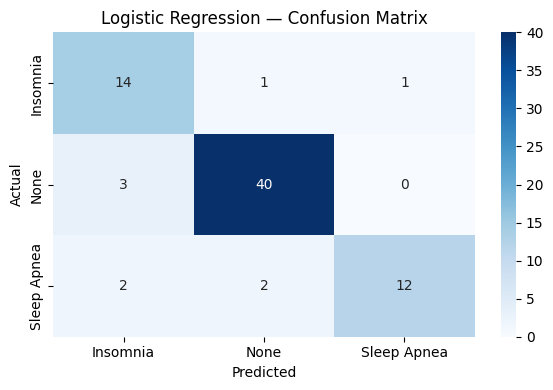

In [5]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le_disorder.classes_,
            yticklabels=le_disorder.classes_)
plt.title('Logistic Regression — Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()